Urban Data Science & Smart Cities <br>
URSP688Y Spring 2025<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Demo 7 - Geospatial Data

- Coordinate systems
- Points from XY
- Loading shapefiles and geojsons
- Proximity analysis
    - Measuring distance
    - Buffering
- Overlay analysis
- Spatial joining

## Geospatial data fundamentals
- Basic geometry types:
    - Points
    - Linestrings
    - Polygons

<img alt="points, lines, and polygons" width=500 src="https://datacarpentry.org/organization-geospatial/fig/dc-spatial-vector/pnt_line_poly.png">

- Spatial analysis (with vector data) is essentially just Euclidean geometry (remember the Pythagorean theorem?)

<img alt="pythagorean theorem" width=500 src="https://www.katesmathlessons.com/uploads/1/6/1/0/1610286/published/how-to-use-the-pythagorean-theorem-to-find-distance-between-points-on-coordinate-plane-2.png?1595954050">

## Geospatial data are everywhere

DC affordable housing: https://opendata.dc.gov/datasets/DCGIS::affordable-housing/about

In [ ]:
# Install Geopandas

# ! conda install -y geopandas

In [1]:
# Import dependencies
import pandas as pd
import geopandas as gpd

## Make points from CSV

In [8]:
# ! Load CSV
#df=pd.read.csv(affordable_housing.csv)
df = pd.read_csv('Affordable_Housing.csv')
df.head(1)
df.columns.tolist()

['X',
 'Y',
 'OBJECTID',
 'MAR_WARD',
 'ADDRESS',
 'PROJECT_NAME',
 'STATUS_PUBLIC',
 'AGENCY_CALCULATED',
 'TOTAL_AFFORDABLE_UNITS',
 'LATITUDE',
 'LONGITUDE',
 'AFFORDABLE_UNITS_AT_0_30_AMI',
 'AFFORDABLE_UNITS_AT_31_50_AMI',
 'AFFORDABLE_UNITS_AT_51_60_AMI',
 'AFFORDABLE_UNITS_AT_61_80_AMI',
 'AFFORDABLE_UNITS_AT_81_AMI',
 'CASE_ID',
 'MAR_ID',
 'XCOORD',
 'YCOORD',
 'FULLADDRESS',
 'GIS_LAST_MOD_DTTM']

In [9]:
# ! Use gpd.points_from_xy to make geometries
points = gpd.points_from_xy(df['LONGITUDE'],df['LATITUDE'])

In [10]:
# ! Use geometries to make a geodataframe with CRS
gpd.GeoDataFrame(
    df,
    geometry=points,
    crs=4326
)

,X,Y,OBJECTID,MAR_WARD,ADDRESS,PROJECT_NAME,STATUS_PUBLIC,AGENCY_CALCULATED,TOTAL_AFFORDABLE_UNITS,LATITUDE,...,AFFORDABLE_UNITS_AT_51_60_AMI,AFFORDABLE_UNITS_AT_61_80_AMI,AFFORDABLE_UNITS_AT_81_AMI,CASE_ID,MAR_ID,XCOORD,YCOORD,FULLADDRESS,GIS_LAST_MOD_DTTM,geometry
0,-77.009383,38.910255,89281,Ward 6,"1520 North Capitol Street Northwest, Washingto...",Cycle House,Under Construction,DMPED DHCD,18,38.910248,...,12,0,0,NaN,331764,399186.36,138042.91,1520 NORTH CAPITOL STREET NW,2024/02/05 05:00:27+00,POINT (-77.00938 38.91025)
1,-77.009436,38.906403,89282,Ward 6,"1200 North Capitol Street Northwest, Washingto...",Tyler House Apartments,Completed 2015 to Date,DCHFA,284,38.906396,...,284,0,0,NaN,237128,399181.75,137615.28,1200 NORTH CAPITOL STREET NW,2024/02/05 05:00:27+00,POINT (-77.00943 38.9064)
2,-77.030061,38.962519,89283,Ward 4,"5922 13th Street Northwest, Washington, Distri...",Valencia Apartments,Completed 2015 to Date,DHCD,29,38.962511,...,29,0,0,NaN,243483,397394.87,143845.04,5922 13TH STREET NW,2024/02/05 05:00:27+00,POINT (-77.03006 38.96251)
3,-76.950868,38.922332,89284,Ward 5,"3814 Fort Lincoln Drive Northeast, Washington,...",Villages at Dakota Crossing Phase III,Completed 2015 to Date,DMPED,24,38.922333,...,0,24,0,NaN,310077,404260.75,139384.60,3814 FORT LINCOLN DRIVE NE,2024/02/05 05:00:27+00,POINT (-76.95084 38.92233)
4,-77.033056,38.967357,89285,Ward 4,"1388 Tuckerman Street Northwest, Washington, D...",Vizcaya Apartments,Completed 2015 to Date,DHCD,17,38.967349,...,17,0,0,NaN,257527,397135.52,144382.12,1388 TUCKERMAN STREET NW,2024/02/05 05:00:27+00,POINT (-77.03305 38.96735)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,-77.022849,38.955067,90154,Ward 4,"710 Jefferson Street Northwest, Washington, Di...",710 Jefferson St NW,Completed 2015 to Date,DHCD,14,38.955059,...,0,2,0,NaN,250236,398019.73,143017.57,710 JEFFERSON STREET NW,2024/02/05 05:00:27+00,POINT (-77.02285 38.95506)
874,-76.932190,38.884980,90155,Ward 7,"4922 Call Place Southeast, Washington, Distric...",Amber Overlook,Completed 2015 to Date,DHCD,32,38.884973,...,0,26,0,NaN,145732,405883.52,135239.33,4922 CALL PLACE SE,2024/02/05 05:00:27+00,POINT (-76.93219 38.88497)
875,-76.989295,38.882209,90156,Ward 6,"1220 Pennsylvania Avenue Southeast, Washington...",Rushmore,Completed 2015 to Date,DHCD,11,38.882208,...,10,0,0,NaN,314729,400929.03,134929.53,1220 PENNSYLVANIA AVENUE SE,2024/02/05 05:00:27+00,POINT (-76.98941 38.88221)
876,-77.022682,38.917214,90157,Ward 1,"2009 8th Street Northwest, Washington, Distric...",2009 8th St NW,Completed 2015 to Date,DHCD,10,38.917206,...,9,0,0,NaN,242769,398033.11,138815.59,2009 8TH STREET NW,2024/02/05 05:00:27+00,POINT (-77.02268 38.91721)


In [ ]:
# ! Plot geodataframe

## Measuring proximity

### How far is each affordable housing project from Metro Center?
- Map projections

In [11]:
# Let's start by reloading the data with more descriptive variable names so we don't get confused
projects_df = pd.read_csv('Affordable_Housing.csv')
projects_gdf = gpd.GeoDataFrame(projects_df, geometry=gpd.points_from_xy(projects_df['LONGITUDE'], projects_df['LATITUDE']), crs=4326)

metro_center_lon = -77.0312124
metro_center_lat = 38.898202
metro_center_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy([metro_center_lon], [metro_center_lat]), crs=4326)

In [12]:
# What's wrong here?
projects_gdf.distance(metro_center_gdf.geometry.iloc[0])

/var/folders/hz/vfghrljj3vx2y4q32zkszc040000gp/T/ipykernel_26758/1150215707.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  projects_gdf.distance(metro_center_gdf.geometry.iloc[0])


0      0.024934
1      0.023269
2      0.064320
3      0.083922
4      0.069172
         ...   
873    0.057469
874    0.099904
875    0.044756
876    0.020832
877    0.018455
Length: 878, dtype: float64

## UTM Zones

[Universal Transverse Mercator](https://en.wikipedia.org/wiki/Universal_Transverse_Mercator_coordinate_system) Zones

The UTM system divides the globe into 120 zones, 60 each in the northern and southern hemispheres. It uses Transverse Mercator projections to minimize shape and distance distortion for localized measurements within each zone.

<img alt="utm slices" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/UTM-Zones-Globe-2.png">

<img alt="utm standard line" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/Universe-Transverse-Mercator-Cylinder.png">

1. [What UTM zone am I in?](https://mangomap.com/robertyoung/maps/69585/what-utm-zone-am-i-in-#)
2. [What is the EPSG code for that zone?](https://www.google.com/search?q=epsg+code+for+UTM18N&rlz=1C5GCCM_en&oq=epsg+code+for+UTM18N&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigATIHCAYQIRiPAjIHCAcQIRiPAtIBCDcxMDJqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8)

In [13]:
# Reproject into the local UTM zone
utm18n = 32618# ! Look up EPSG code for UTM zone for Washington DC

# ! Project both projects and metro center geodataframes into utm

# ! Calculate distance between each project and metro center

In [ ]:
# ! Get projects that are within a mile of metro center

In [ ]:
# ! Map projects with .explore()

### Which projects are within 1 mile of Metro Center or Columbia Heights?

#### Another approach: Buffer and spatial join

In [ ]:
# Define multiple locations
metro_locations = {
    'Metro Center': {
        'lon': -77.0312124, 
        'lat': 38.898202
    },
    'Columbia Heights': {
        'lon': -77.0350154, 
        'lat': 38.92890
    },
}

# Convert to a geodataframe
metro_locations_df = pd.DataFrame.from_dict(metro_locations, orient='index')
metro_locations_points = gpd.points_from_xy(metro_locations_df['lon'], metro_locations_df['lat'])
metro_locations_gdf = gpd.GeoDataFrame(metro_locations_df, geometry=metro_locations_points, crs=4326)
metro_locations_gdf = metro_locations_gdf.to_crs(utm18n)

In [ ]:
# Buffer metro locations
metro_locations_buffer = metro_locations_gdf.buffer(threshold_dist)

In [ ]:
metro_locations_buffer.explore(tiles='CartoDB positron')

In [ ]:
metro_locations_buffer_gdf = gpd.GeoDataFrame(geometry=metro_locations_buffer)
metro_locations_buffer_gdf

In [ ]:
projects_near_metro = gpd.sjoin(projects_gdf, metro_locations_buffer_gdf)

In [ ]:
projects_near_metro.head()

In [ ]:
projects_near_metro = projects_near_metro.rename(columns={'index_right':'near_metro'})

In [ ]:
projects_near_metro['near_metro'].value_counts()

In [ ]:
projects_near_metro.explore(column='near_metro', tiles='CartoDB positron')

## Overlay

### How many projects are in each census tract?

- [Population by Tract from Census Reporter](https://censusreporter.org/data/table/?table=B01003&geo_ids=16000US1150000,140|16000US1150000&primary_geo_id=16000US1150000)

In [14]:
# Load tract polygons from geojson,Census Reporter
tracts_gdf = gpd.read_file('acs2023_5yr_B01003_14000US11001007409.geojson')
# Project into local UTM
tracts_gdf = tracts_gdf.to_crs(utm18n)
# Only keep records that are tracts (there's pesky one for all of Washington DC)
tracts_gdf = tracts_gdf[tracts_gdf.geoid.str.len() == 18]

<Axes: >

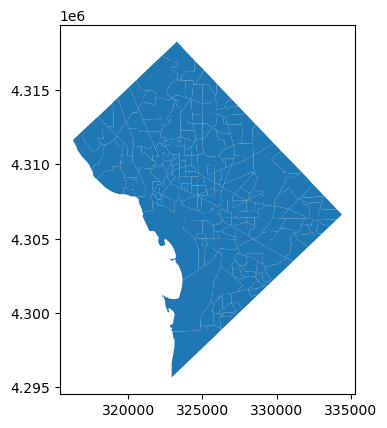

In [15]:
tracts_gdf.plot()

In [17]:
# Ensure projects and tracts are in the same projection (CRS: coordinate reference system)
assert projects_gdf.crs == tracts_gdf.crs

AssertionError: 

In [18]:
# Spatially join projects to tracts
tracts_with_projects_gdf = gpd.sjoin(tracts_gdf, projects_gdf, how='left')

/var/folders/hz/vfghrljj3vx2y4q32zkszc040000gp/T/ipykernel_26758/2376093892.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:32618
Right CRS: EPSG:4326

  tracts_with_projects_gdf = gpd.sjoin(tracts_gdf, projects_gdf, how='left')


In [ ]:
tracts_with_projects_gdf.head()

In [ ]:
# Count unique projects in each tract
project_counts = tracts_with_projects_gdf.groupby('geoid').index_right.nunique()

project_counts

In [ ]:
# Join counts onto tracts
tracts_with_counts_gdf = tracts_gdf.merge(project_counts, left_on='geoid', right_index=True)

In [ ]:
tracts_with_counts_gdf.head()

In [ ]:
# Cleanup columns
columns = {
    'geoid':'geoid',
    'B01003001':'population',
    'index_right':'projects',
    'geometry':'geometry'
}
tracts_with_counts_gdf = tracts_with_counts_gdf[columns.keys()].rename(columns=columns)

In [ ]:
tracts_with_counts_gdf.head()

In [ ]:
tracts_with_counts_gdf.plot(column='projects')

In [ ]:
# Calculate projects per population
tracts_with_counts_gdf['projects_per_population'] = tracts_with_counts_gdf['projects'] / tracts_with_counts_gdf['population']

In [ ]:
tracts_with_counts_gdf.plot(column='projects_per_population')

### How many units are in each census tract?

In [ ]:
# Use a the general 'agg' method to aggregate multiple columns at once by different methods
#Census Reporter
project_stats = tracts_with_projects_gdf.groupby('geoid').agg({
    'index_right': 'nunique',
    'TOTAL_AFFORDABLE_UNITS': 'sum',
})

tracts_with_counts_gdf = tracts_gdf.merge(project_stats, left_on='geoid', right_index=True)

columns = {
    'geoid':'geoid',
    'B01003001':'population',
    'index_right':'projects',
    'TOTAL_AFFORDABLE_UNITS': 'units',
    'geometry':'geometry',
}
tracts_with_counts_gdf = tracts_with_counts_gdf[columns.keys()].rename(columns=columns)

In [ ]:
tracts_with_counts_gdf.plot(column='units')